<a href="https://colab.research.google.com/github/sherlyazkiah/PCVK/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3. Make an image histogram like the following histogram output based on the flowchart below :
(Use image lena.jpg)

<BarContainer object of 256 artists>

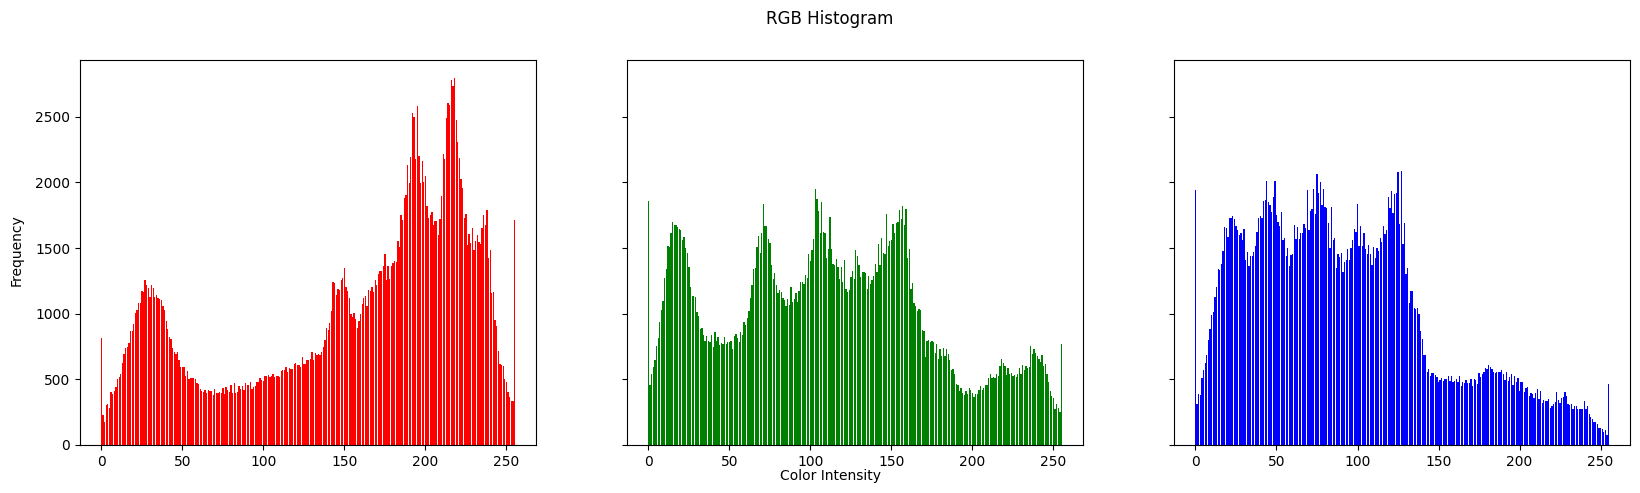

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('RGB Histogram')
fig.text(0.09, 0.5, 'Frequency', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Color Intensity', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

4. After working on question no. 3, make the same image histogram but use the library that is owned by NumPy, namely " histogram ". Compare the results. Does the output appear the same?

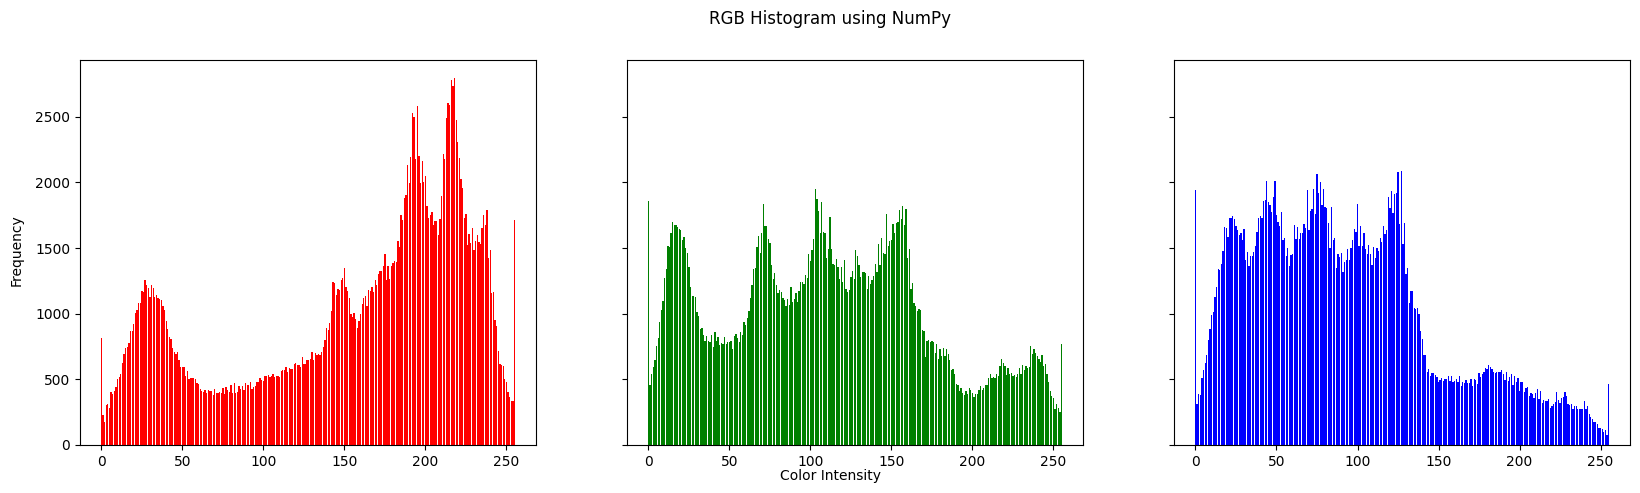

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split RGB channels
r = img[:, :, 0]
g = img[:, :, 1]
b = img[:, :, 2]

# Compute histogram using NumPy
hist_r, bins_r = np.histogram(r.flatten(), bins=256, range=[0, 256])
hist_g, bins_g = np.histogram(g.flatten(), bins=256, range=[0, 256])
hist_b, bins_b = np.histogram(b.flatten(), bins=256, range=[0, 256])

# Plot
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('RGB Histogram using NumPy')
fig.text(0.09, 0.5, 'Frequency', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Color Intensity', ha='center')

axs[0].bar(names, hist_r, color='red')
axs[1].bar(names, hist_g, color='green')
axs[2].bar(names, hist_b, color='blue')
plt.show()


5. Make an image histogram such as the output equalization histogram and also the image display before and after the following equalization histogram process based on the flowchart below : (Use image lena_lc .jpg)

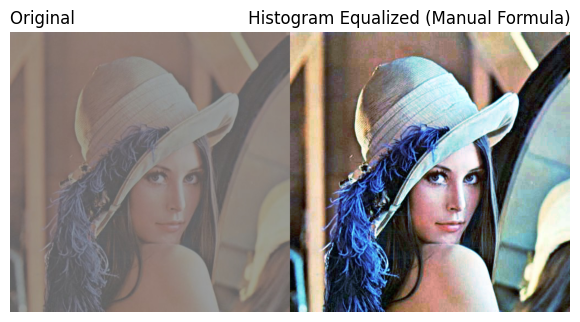

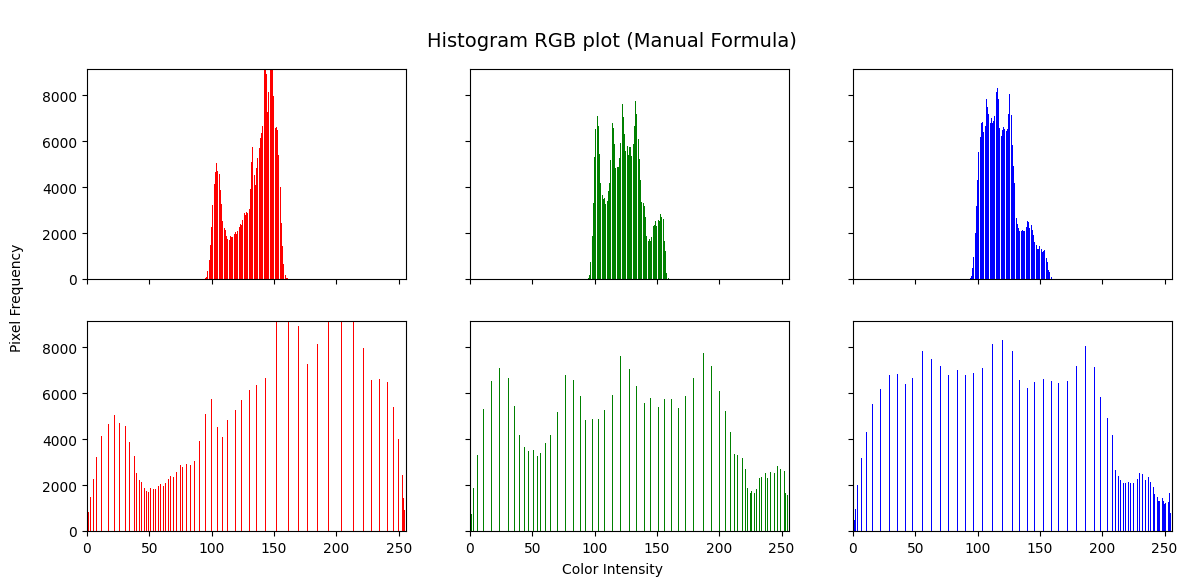

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Get dimensions
h, w, _ = img.shape
total_pixels = h * w
k = 8  # 8-bit image

# Manual Histogram Equalization using formula
img_eq = np.zeros_like(img)
for ch in range(3):  # R, G, B
    # Hitung histogram
    hist, _ = np.histogram(img[:, :, ch].flatten(), bins=256, range=[0,256])
    # CDF (cumulative distribution)
    cdf = np.cumsum(hist)
    # Rumus manual: Ko = round((Ci * (2^k - 1)) / (w*h))
    Ko = np.round((cdf * (2**k - 1)) / total_pixels).astype('uint8')
    # Mapping hasil equalization
    img_eq[:, :, ch] = Ko[img[:, :, ch]]

plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.imshow(np.hstack((img, img_eq)))
plt.title('Original                                 Histogram Equalized (Manual Formula)')
plt.axis('off')

# Prepare histograms
colors = ('r','g','b')
fig, axs = plt.subplots(2, 3, figsize=(14,6), sharex=True, sharey=True)
fig.suptitle('\nHistogram RGB plot (Manual Formula)', fontsize=14)
fig.text(0.5, 0.04, 'Color Intensity', ha='center')
fig.text(0.07, 0.5, 'Pixel Frequency', va='center', rotation='vertical')

# Original histograms
for i, col in enumerate(colors):
    hist = cv.calcHist([img], [i], None, [256], [0,256])
    axs[0, i].bar(np.arange(256), hist.flatten(), color=col)
    axs[0, i].set_xlim([0,256])
    axs[0, i].set_ylim([0, hist.max()*1.1])

# Equalized histograms
for i, col in enumerate(colors):
    hist = cv.calcHist([img_eq], [i], None, [256], [0,256])
    axs[1, i].bar(np.arange(256), hist.flatten(), color=col)
    axs[1, i].set_xlim([0,256])
    axs[1, i].set_ylim([0, hist.max()*1.1])

plt.show()

6. After working on question no. 5, make the same image histogram but use the library owned by CV2, namely " equalizeHist ". Compare the results. Does the output appear the same?

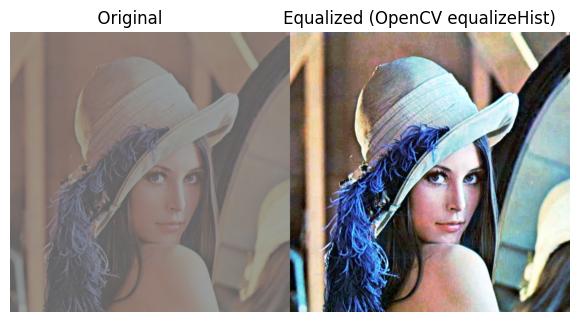

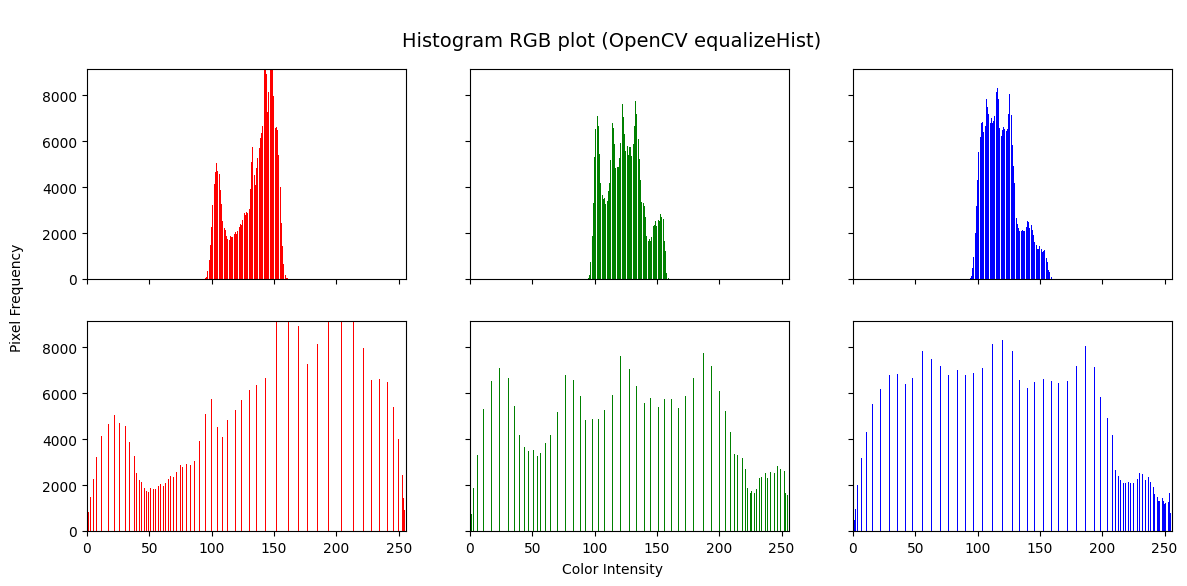

In [14]:
image = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Equalize each RGB channel using OpenCV
b, g, r = cv.split(image)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

# Merge equalized channels back into one image
equalized_img = cv.merge((b_equalized, g_equalized, r_equalized))

plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.imshow(np.hstack((image, equalized_img)))
plt.title('              Original                       Equalized (OpenCV equalizeHist)')
plt.axis('off')

# Prepare histograms
colors = ('r','g','b')
fig, axs = plt.subplots(2, 3, figsize=(14,6), sharex=True, sharey=True)
fig.suptitle('\nHistogram RGB plot (OpenCV equalizeHist)', fontsize=14)
fig.text(0.5, 0.04, 'Color Intensity', ha='center')
fig.text(0.07, 0.5, 'Pixel Frequency', va='center', rotation='vertical')

# Original histograms
for i, col in enumerate(colors):
    hist = cv.calcHist([image], [i], None, [256], [0,256])
    axs[0, i].bar(np.arange(256), hist.flatten(), color=col)
    axs[0, i].set_xlim([0,256])
    axs[0, i].set_ylim([0, hist.max()*1.1])

# Equalized histograms
for i, col in enumerate(colors):
    hist = cv.calcHist([equalized_img], [i], None, [256], [0,256])
    axs[1, i].bar(np.arange(256), hist.flatten(), color=col)
    axs[1, i].set_xlim([0,256])
    axs[1, i].set_ylim([0, hist.max()*1.1])

plt.show()

7.	Do the mapping process of 16 million RGB colors into just 8 colors, namely black, green, yellow, blue, cyan, magenta, white as shown in the following output based on the flowchart below! (Use the image testlena .jpg)

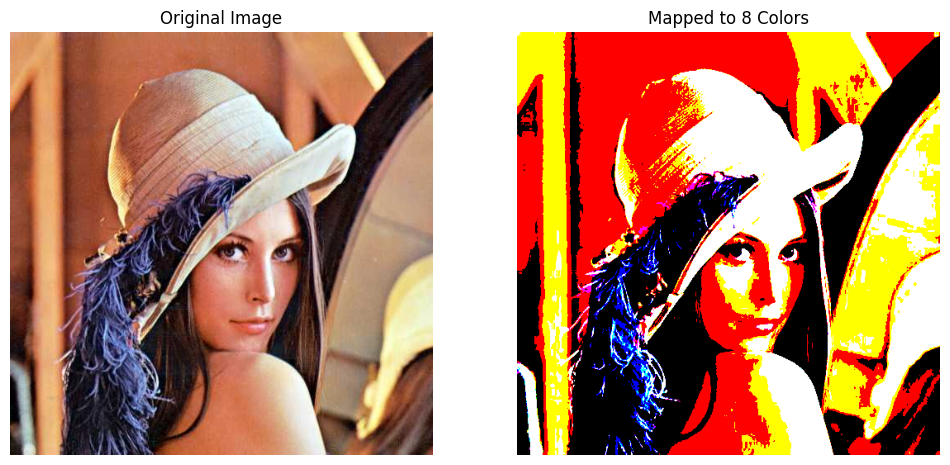

In [17]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Define 8 base colors (RGB)
colors = np.array([
    [0, 0, 0],        # Black
    [0, 255, 0],      # Green
    [255, 255, 0],    # Yellow
    [0, 0, 255],      # Blue
    [0, 255, 255],    # Cyan
    [255, 0, 255],    # Magenta
    [255, 255, 255]   # White
], dtype=np.uint8)

# Flatten image (for processing per pixel)
pixels = img.reshape((-1, 3))

# Apply Threshold per Channel
mapped = np.zeros_like(pixels)

for i, pixel in enumerate(pixels):
    r, g, b = pixel
    r_bin = 255 if r > 127 else 0
    g_bin = 255 if g > 127 else 0
    b_bin = 255 if b > 127 else 0
    mapped[i] = [r_bin, g_bin, b_bin]


# Reshape back to original image size
mapped_img = mapped.reshape(img.shape)

# Display Results
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mapped_img)
plt.title('Mapped to 8 Colors')
plt.axis('off')

plt.show()

8. Do the Floyd and Steinberg dithering process like the following output (initial image
display, and after dithering display) based on the flowchart below! (Use wiki.jpg
image)

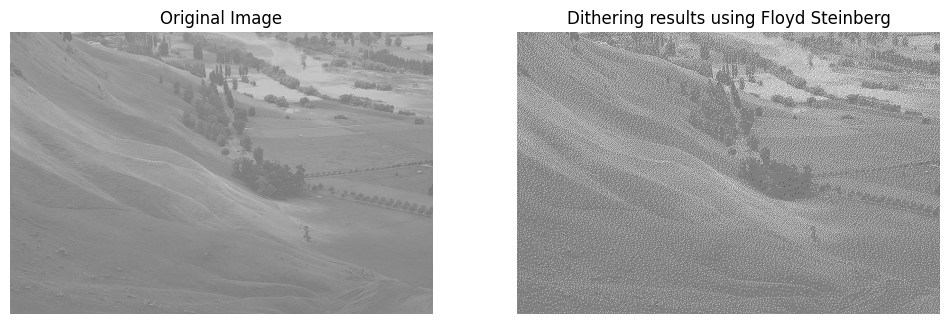

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/wiki.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
ori = img.copy()

# Convert to float for calculations
img = img.astype(float)

# Define threshold function
def threshold(value):
    if value > 255:
        return 255
    elif value < 0:
        return 0
    else:
        return value

# Set number of quantization levels (jarakPixel)
jarakPixel = 1  # minimal 1 as in flowchart

# Get image dimensions
height, width, channels = img.shape

# Floyd–Steinberg Dithering process
for y in range(height - 1):
    for x in range(1, width - 1):
        for c in range(channels):  # R, G, B
            old_pixel = img[y, x, c]

            # Quantize pixel to nearest level (0 or 255)
            new_pixel = np.round(jarakPixel * old_pixel / 255.0) * (255 / jarakPixel)
            img[y, x, c] = new_pixel

            # Compute quantization error
            error = old_pixel - new_pixel

            # Distribute error to neighboring pixels (R1–R4)
            img[y, x+1, c]     = threshold(img[y, x+1, c]     + error * 7/16)
            img[y+1, x-1, c]   = threshold(img[y+1, x-1, c]   + error * 3/16)
            img[y+1, x, c]     = threshold(img[y+1, x, c]     + error * 5/16)
            img[y+1, x+1, c]   = threshold(img[y+1, x+1, c]   + error * 1/16)

# Convert back to uint8
dithered = np.clip(img, 0, 255).astype(np.uint8)

# Display results
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(ori)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dithered)
plt.title('Dithering results using Floyd Steinberg')
plt.axis('off')
plt.show()
